Index(['Title', 'Name', 'Review Date', 'Airline', 'Verified', 'Reviews',
       'Type of Traveller', 'Month Flown', 'Route', 'Class', 'Seat Comfort',
       'Staff Service', 'Food & Beverages', 'Inflight Entertainment',
       'Value For Money', 'Overall Rating', 'Recommended'],
      dtype='object')
✅ Turkish Airlines Reviews Found: 1685


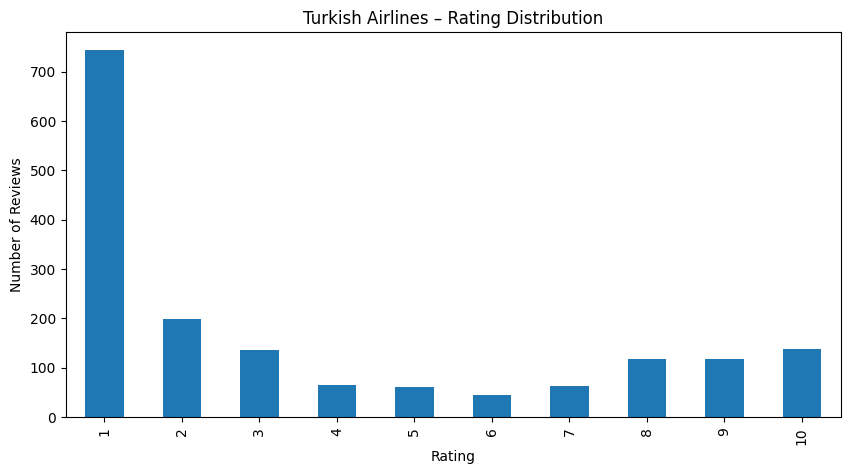

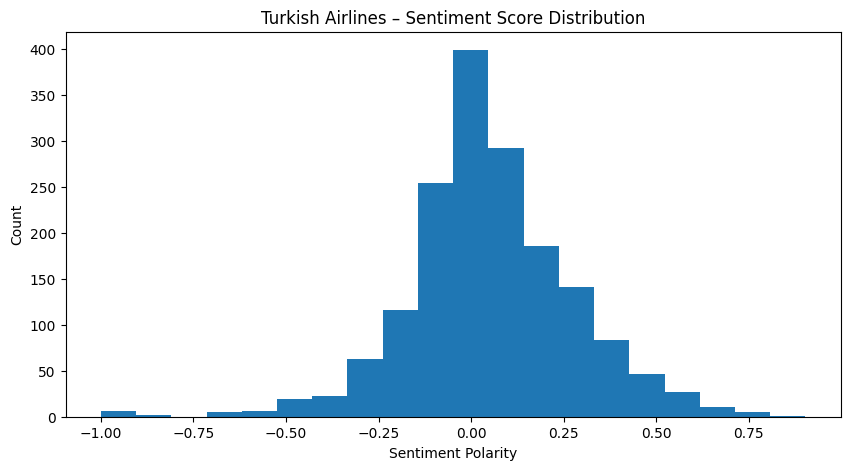

✨ MOST COMMON WORDS ✨
words
the        13153
to         10420
and         8221
i           6293
a           5353
was         5071
in          3690
of          3375
for         3173
they        2927
my          2909
on          2728
with        2664
we          2555
flight      2544
that        2326
not         2273
is          2175
turkish     2007
at          1891
Name: count, dtype: int64


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob

df = pd.read_csv('/kaggle/input/airlines-reviews/airlines_reviews.csv')

print(df.columns)

# Correct columns (case sensitive)
airline_col = 'Airline'
rating_col = 'Overall Rating'
text_col = 'Reviews'

df_tk = df[df[airline_col].str.contains("Turkish", case=False, na=False)]
print("✅ Turkish Airlines Reviews Found:", len(df_tk))

# ---------------- rating chart --------------
plt.figure(figsize=(10,5))
df_tk[rating_col].value_counts().sort_index().plot(kind='bar')
plt.title("Turkish Airlines – Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

# --------------- sentiment --------------------
df_tk = df_tk.copy()
df_tk.loc[:, 'sentiment'] = df_tk[text_col].fillna("").apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

plt.figure(figsize=(10,5))
plt.hist(df_tk['sentiment'], bins=20)
plt.title("Turkish Airlines – Sentiment Score Distribution")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Count")
plt.show()

# --------------- word frequency ------------------
df_tk.loc[:, 'words'] = df_tk[text_col].fillna("").str.lower().str.split()
all_words = df_tk['words'].explode()
common_words = all_words.value_counts().head(20)
print("✨ MOST COMMON WORDS ✨")
print(common_words)
